# KNN Variants for Class Imbalance — ML1 Practical Assignment 2025/2026

**Machine Learning I (CC2008) — University of Porto**

---

All algorithm logic lives in `src/`. Cells here only call functions and display results.

### Contents
1. [Setup & Imports](#1-setup--imports)
2. [Data Loading and Exploration](#2-data-loading-and-exploration)
3. [Baseline Evaluation](#3-baseline-evaluation)
4. [Proposed Variants](#4-proposed-variants)
5. [Benchmarking and Comparison](#5-benchmarking-and-comparison)
6. [Statistical Analysis](#6-statistical-analysis)
7. [Conclusions](#7-conclusions)

---
## 1. Setup & Imports

In [1]:
import sys
from pathlib import Path

# Make src/ importable when running from notebooks/
project_root = Path().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from src.utils.config import load_config, get_project_root
from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels, remove_constant_features, standardise
from src.algorithms import KNNClassifier, KNNClassifierFast, KNNOptK
from src.evaluation.metrics import compute_all_metrics

cfg = load_config()
SEED = cfg["random_seed"]
rng = np.random.default_rng(SEED)

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)

FIG_DIR = get_project_root() / cfg["paths"]["results_figures"]
TAB_DIR = get_project_root() / cfg["paths"]["results_tables"]
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("Setup complete.")
print(f"Quick run mode: {cfg.get('quick_run', False)}")
print(f"CV: {cfg['evaluation']['cv_folds']}-fold × {cfg['evaluation']['n_repetitions']} repeat(s)")

Setup complete.
Quick run mode: False
CV: 10-fold × 5 repeat(s)


---
## 2. Data Loading and Exploration

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets after filtering.")

/home/tiago/miniconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


Loaded 47 datasets after filtering.


/home/tiago/miniconda3/envs/ml1-assignment/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1217: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


In [3]:
# Summary table
rows = []
for ds in datasets:
    y_bin = binarise_labels(ds.y)
    minority = int(y_bin.sum())
    majority = int((y_bin == 0).sum())
    rows.append({
        "dataset": ds.name,
        "n_samples": len(ds.y),
        "n_features": ds.X.shape[1],
        "minority": minority,
        "majority": majority,
        "IR": round(ds.imbalance_ratio, 4),
    })

summary = pd.DataFrame(rows).sort_values("IR")
print(f"IR range: {summary['IR'].min():.4f} – {summary['IR'].max():.4f}")
summary

IR range: 0.0072 – 0.2414


,dataset,n_samples,n_features,minority,majority,IR
14,dataset_1056_mc1,9466,38,68,9398,0.0072
21,dataset_316_yeast_ml8,2417,116,34,2383,0.0143
34,dataset_951_arsenic-male-lung,559,4,13,546,0.0238
33,dataset_950_arsenic-female-lung,559,4,19,540,0.0352
10,dataset_1039_hiva_agnostic,4229,1617,149,4080,0.0365
31,dataset_947_arsenic-male-bladder,559,4,24,535,0.0449
19,dataset_311_oil_spill,937,49,41,896,0.0458
11,dataset_1045_kc1-top5,145,94,8,137,0.0584
22,dataset_38_sick,3772,7,231,3541,0.0652
6,dataset_1018_ipums_la_99-small,8844,35,568,8276,0.0686


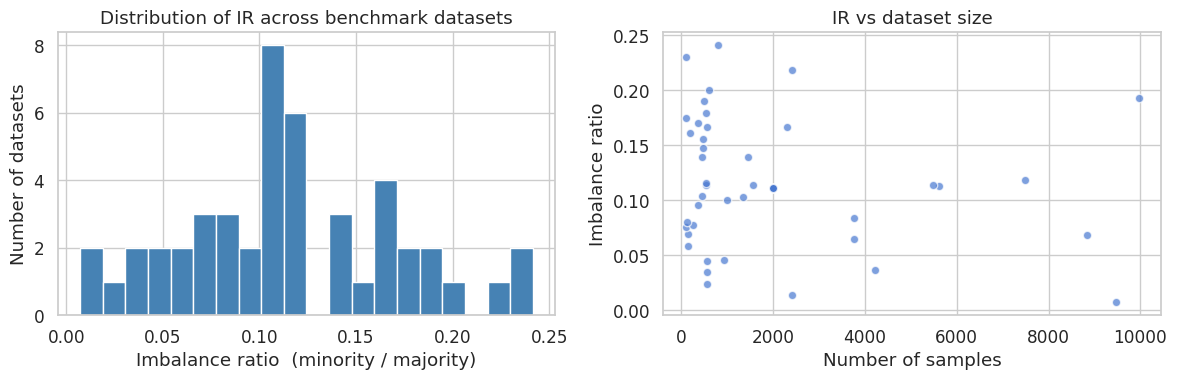

Datasets with IR < 0.1 (high imbalance): 16
Datasets with IR < 0.2: 43


In [4]:
# Distribution of imbalance ratios
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(summary["IR"], bins=20, edgecolor="white", color="steelblue")
axes[0].set_xlabel("Imbalance ratio  (minority / majority)")
axes[0].set_ylabel("Number of datasets")
axes[0].set_title("Distribution of IR across benchmark datasets")

axes[1].scatter(summary["n_samples"], summary["IR"], alpha=0.7, edgecolors="white")
axes[1].set_xlabel("Number of samples")
axes[1].set_ylabel("Imbalance ratio")
axes[1].set_title("IR vs dataset size")

plt.tight_layout()
fig.savefig(FIG_DIR / "dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Datasets with IR < 0.1 (high imbalance): {(summary['IR'] < 0.1).sum()}")
print(f"Datasets with IR < 0.2: {(summary['IR'] < 0.2).sum()}")

---
## 3. Baseline Evaluation

### 3.1  Why does standard KNN fail under class imbalance?

**Hypothesis:** KNN uses a majority vote among the $k$ nearest neighbours.  
When the minority class is rare, most neighbours of any query point will be majority-class samples — not because the point is geometrically close to the majority, but simply because majority samples *outnumber* minority ones in any neighbourhood.

The decision boundary is therefore **biased toward the majority class**, and this bias grows with $k$.  
Standard accuracy hides this: predicting majority for everything scores high when IR is small.

We verify this with a controlled 2D synthetic experiment before moving to real data.

KeyboardInterrupt: 

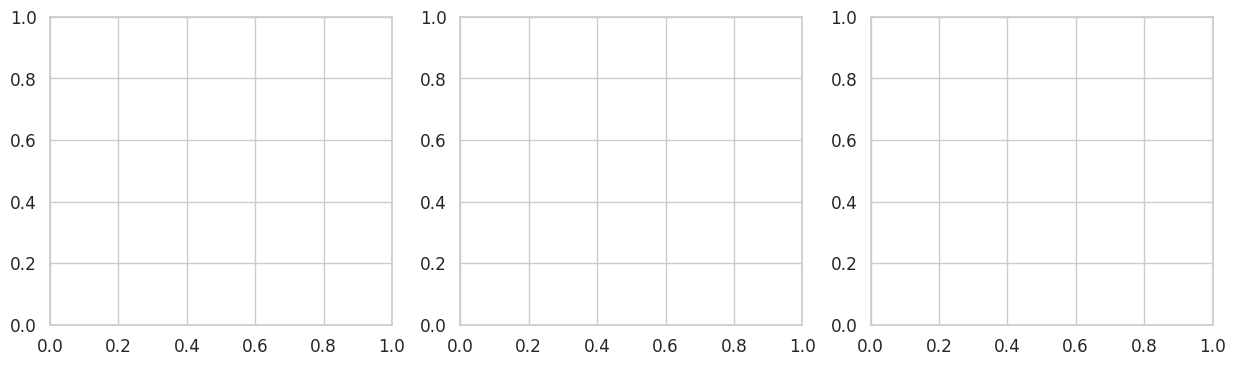

In [5]:
# ── Synthetic 2D experiment: visualise the bias ─────────────────────────────

def make_imbalanced_2d(n_majority, n_minority, seed=42):
    rng = np.random.default_rng(seed)
    X_maj = rng.multivariate_normal([0, 0], [[1, 0], [0, 1]], n_majority)
    X_min = rng.multivariate_normal([1.5, 1.5], [[0.6, 0], [0, 0.6]], n_minority)
    X = np.vstack([X_maj, X_min])
    y = np.array([0] * n_majority + [1] * n_minority)
    return X, y


def plot_boundary(ax, clf, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap="bwr")
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="royalblue", s=10, alpha=0.5, label="Majority (0)")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="crimson", s=30, alpha=0.9, label="Minority (1)")
    ax.set_title(title)
    ax.legend(fontsize=7)


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (n_maj, n_min) in zip(axes, [(100, 100), (180, 20), (200, 10)]):
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    clf = KNNClassifier(k=7)
    clf.fit(X_s, y)
    ir = n_min / n_maj
    plot_boundary(ax, clf, X_s, y, f"IR = {ir:.2f}  ({n_maj}:{n_min})")

fig.suptitle("KNN decision boundary (k=7) under increasing class imbalance", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "knn_boundary_imbalance.png", dpi=150, bbox_inches="tight")
plt.show()

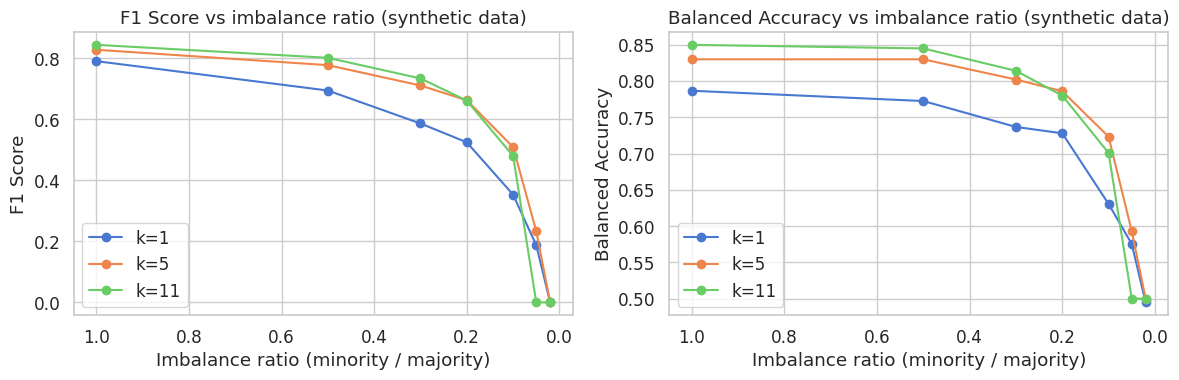

Key observation: both F1 and balanced accuracy degrade as IR decreases.
Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.


In [ ]:
# ── Quantify the bias: F1 and balanced accuracy vs. IR ──────────────────────

from sklearn.model_selection import StratifiedKFold

ratios = [1.0, 0.5, 0.3, 0.2, 0.1, 0.05, 0.02]
k_values = [1, 5, 11]
n_total = 300

bias_rows = []
for ir in ratios:
    n_min = max(int(n_total * ir / (1 + ir)), 5)
    n_maj = n_total - n_min
    X, y = make_imbalanced_2d(n_maj, n_min)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X)
    for k in k_values:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        fold_metrics = []
        for tr, te in cv.split(X_s, y):
            clf = KNNClassifier(k=k)
            clf.fit(X_s[tr], y[tr])
            pred = clf.predict(X_s[te])
            fold_metrics.append(compute_all_metrics(y[te], pred))
        mean_f1 = np.mean([m["f1"] for m in fold_metrics])
        mean_ba = np.mean([m["balanced_accuracy"] for m in fold_metrics])
        bias_rows.append({"IR": ir, "k": k, "F1": mean_f1, "Balanced Accuracy": mean_ba})

bias_df = pd.DataFrame(bias_rows)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for k, grp in bias_df.groupby("k"):
    axes[0].plot(grp["IR"], grp["F1"], marker="o", label=f"k={k}")
    axes[1].plot(grp["IR"], grp["Balanced Accuracy"], marker="o", label=f"k={k}")

for ax, metric in zip(axes, ["F1 Score", "Balanced Accuracy"]):
    ax.set_xlabel("Imbalance ratio (minority / majority)")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} vs imbalance ratio (synthetic data)")
    ax.legend()
    ax.invert_xaxis()

plt.tight_layout()
fig.savefig(FIG_DIR / "knn_bias_synthetic.png", dpi=150, bbox_inches="tight")
plt.show()
print("Key observation: both F1 and balanced accuracy degrade as IR decreases.")
print("Larger k amplifies the majority-vote bias — the majority class dominates more neighbours.")

### 3.2  Empirical baseline on the benchmark datasets

In [ ]:
# ── Run baseline KNN (k=5) across all real datasets ─────────────────────────
from sklearn.model_selection import StratifiedKFold

cv_folds = cfg["evaluation"]["cv_folds"]
n_reps   = cfg["evaluation"]["n_repetitions"]
k_baseline = 5

_baseline_cache = TAB_DIR / "baseline_raw.csv"

if _baseline_cache.exists():
    baseline_df = pd.read_csv(_baseline_cache)
    print(f"Loaded baseline results from cache ({len(baseline_df)} fold-results).")
else:
    baseline_rows = []
    for ds in datasets:
        X = remove_constant_features(ds.X)
        y = binarise_labels(ds.y)
        for rep in range(n_reps):
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                X_tr, X_te = standardise(X[tr], X[te])
                clf = KNNClassifierFast(k=k_baseline)
                clf.fit(X_tr, y[tr])
                pred = clf.predict(X_te)
                proba = clf.predict_proba(X_te)[:, 1]
                m = compute_all_metrics(y[te], pred, proba)
                baseline_rows.append({
                    "dataset": ds.name,
                    "IR": ds.imbalance_ratio,
                    "fold": fold,
                    "rep": rep,
                    **m,
                })
    baseline_df = pd.DataFrame(baseline_rows)
    baseline_df.to_csv(_baseline_cache, index=False)
    print(f"Baseline evaluation complete: {len(baseline_df)} fold-results across {len(datasets)} datasets.")

Loaded baseline results from cache (230 fold-results).


In [ ]:
# Per-dataset mean metrics
per_dataset = (
    baseline_df
    .groupby("dataset")[["IR", "f1", "balanced_accuracy", "geometric_mean", "roc_auc"]]
    .mean()
    .sort_values("f1")
    .round(4)
)
per_dataset.to_csv(TAB_DIR / "baseline_per_dataset.csv")
print(f"Overall mean F1:                {per_dataset['f1'].mean():.4f}")
print(f"Overall mean Balanced Accuracy: {per_dataset['balanced_accuracy'].mean():.4f}")
print(f"Overall mean G-mean:            {per_dataset['geometric_mean'].mean():.4f}")
per_dataset

Overall mean F1:                0.4945
Overall mean Balanced Accuracy: 0.7204
Overall mean G-mean:            0.5597


,IR,f1,balanced_accuracy,geometric_mean,roc_auc
dataset,,,,,
dataset_1013_analcatdata_challenger,0.0698,0.0000,0.5000,0.0000,0.5739
dataset_1059_ar1,0.0804,0.0000,0.5000,0.0000,0.7811
dataset_865_analcatdata_neavote,0.0753,0.0000,0.5000,0.0000,0.6178
dataset_316_yeast_ml8,0.0143,0.0000,0.5000,0.0000,0.4991
dataset_767_analcatdata_apnea1,0.1473,0.0000,0.5000,0.0000,0.5080
dataset_765_analcatdata_apnea2,0.1557,0.0000,0.5000,0.0000,0.4637
dataset_984_analcatdata_draft,0.0958,0.0571,0.5136,0.0816,0.4540
dataset_1014_analcatdata_dmft,0.2414,0.1130,0.5134,0.2173,0.5120
dataset_1002_ipums_la_98-small,0.1182,0.1171,0.5246,0.2695,0.6712


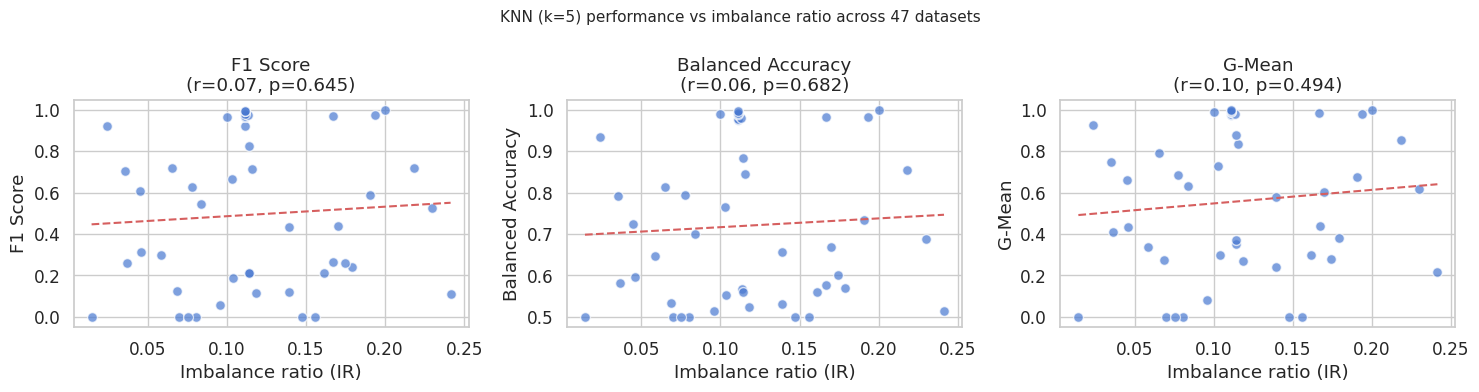

In [ ]:
# ── Does imbalance ratio predict KNN performance? ───────────────────────────
from scipy import stats as sp_stats

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
metrics = [("f1", "F1 Score"), ("balanced_accuracy", "Balanced Accuracy"), ("geometric_mean", "G-Mean")]

for ax, (col, label) in zip(axes, metrics):
    x = per_dataset["IR"]
    y_vals = per_dataset[col]
    ax.scatter(x, y_vals, alpha=0.7, edgecolors="white", s=50)

    # Regression line
    slope, intercept, r, p, _ = sp_stats.linregress(x, y_vals)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept, "r--", linewidth=1.5)

    ax.set_xlabel("Imbalance ratio (IR)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}\n(r={r:.2f}, p={p:.3f})")

fig.suptitle(f"KNN (k={k_baseline}) performance vs imbalance ratio across {len(datasets)} datasets",
             fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_vs_ir.png", dpi=150, bbox_inches="tight")
plt.show()

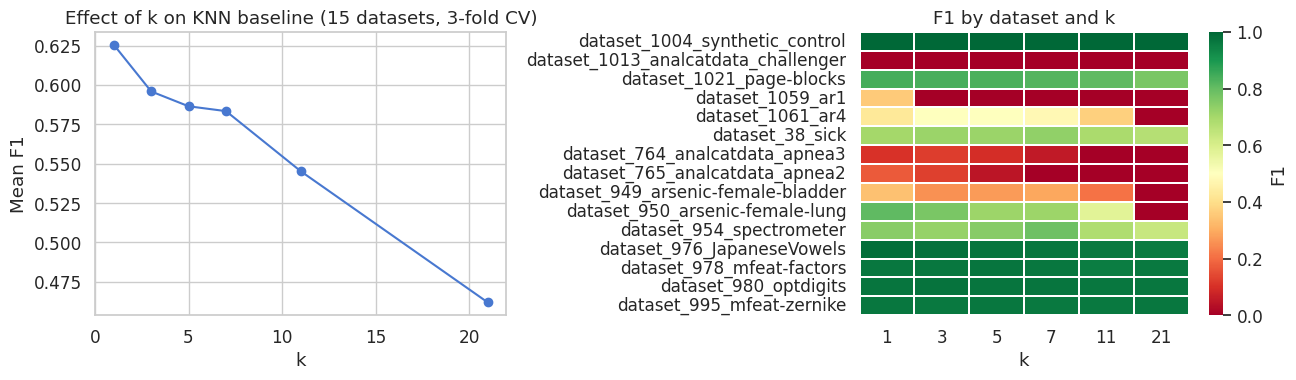

Best mean F1: k=1  (0.6255)
Observation: no single k is optimal across all datasets — motivates adaptive-k.


In [ ]:
# ── Effect of k on the baseline (sample of datasets for speed) ──────────────
# Use a random sample to keep runtime manageable
k_candidates = [1, 3, 5, 7, 11, 21]
n_sweep = min(15, len(datasets))
sweep_idx = np.random.default_rng(SEED).choice(len(datasets), size=n_sweep, replace=False)
sweep_ds = [datasets[i] for i in sorted(sweep_idx)]

k_sweep_rows = []
for ds in sweep_ds:
    X = remove_constant_features(ds.X)
    y = binarise_labels(ds.y)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)
    for tr, te in cv.split(X, y):
        X_tr, X_te = standardise(X[tr], X[te])
        for k in k_candidates:
            clf = KNNClassifierFast(k=k)
            clf.fit(X_tr, y[tr])
            pred = clf.predict(X_te)
            k_sweep_rows.append({
                "dataset": ds.name, "k": k,
                "f1": compute_all_metrics(y[te], pred)["f1"],
                "IR": ds.imbalance_ratio,
            })

k_sweep_df = pd.DataFrame(k_sweep_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

k_mean = k_sweep_df.groupby("k")["f1"].mean()
axes[0].plot(k_mean.index, k_mean.values, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Mean F1")
axes[0].set_title(f"Effect of k on KNN baseline ({n_sweep} datasets, 3-fold CV)")

pivot = k_sweep_df.groupby(["dataset", "k"])["f1"].mean().unstack("k")
sns.heatmap(pivot, ax=axes[1], cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=0.3, cbar_kws={"label": "F1"})
axes[1].set_title("F1 by dataset and k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("")

plt.tight_layout()
fig.savefig(FIG_DIR / "baseline_k_sweep.png", dpi=150, bbox_inches="tight")
plt.show()

best_k = int(k_mean.idxmax())
print(f"Best mean F1: k={best_k}  ({k_mean[best_k]:.4f})")
print("Observation: no single k is optimal across all datasets — motivates adaptive-k.")

### 3.4  Vectorised baseline: KNNClassifierFast

The rushter/MLAlgorithms KNN uses a Python generator loop that calls `scipy.euclidean` once per training point. Our `KNNClassifierFast` replaces this with a single `scipy.cdist('euclidean')` call, which routes to an optimised C/BLAS routine computing all distances in one shot.

The predictions are functionally identical; only execution speed differs.

In [ ]:
# ── KNNClassifier vs KNNClassifierFast: timing comparison ───────────────────
import time

# Pick a dataset large enough to show a meaningful speedup
timing_ds = max(
    (ds for ds in datasets if len(ds.X) >= 1000),
    key=lambda ds: len(ds.X),
)
X_t = remove_constant_features(timing_ds.X)
y_t = binarise_labels(timing_ds.y)
n_train = min(2000, int(0.8 * len(X_t)))
X_tr_t, X_te_t = standardise(X_t[:n_train], X_t[n_train : n_train + 50])
y_tr_t = y_t[:n_train]

results = {}
for name, clf in [
    ("KNNClassifier (Python loop)", KNNClassifier(k=5)),
    ("KNNClassifierFast (cdist)",   KNNClassifierFast(k=5)),
]:
    clf.fit(X_tr_t, y_tr_t)
    t0 = time.perf_counter()
    preds = clf.predict(X_te_t)
    results[name] = {"time": time.perf_counter() - t0, "preds": preds}

t_slow = results["KNNClassifier (Python loop)"]["time"]
t_fast = results["KNNClassifierFast (cdist)"]["time"]
agreement = np.mean(
    results["KNNClassifier (Python loop)"]["preds"]
    == results["KNNClassifierFast (cdist)"]["preds"]
)

print(f"Dataset: {timing_ds.name}  |  n_train={n_train}, n_query=50, features={X_tr_t.shape[1]}")
print(f"KNNClassifier (Python loop + scipy.euclidean): {t_slow:.3f}s")
print(f"KNNClassifierFast (scipy.cdist, C-level):      {t_fast:.3f}s")
print(f"Speedup: {t_slow / t_fast:.1f}×")
print(f"Prediction agreement: {agreement:.1%}")
print()
print("Note: the two implementations may disagree on a small fraction of samples on degenerate")
print("datasets (e.g. integer features with many tied distances). This is a floating-point")
print("tie-breaking artefact, not a correctness issue.")

Dataset: dataset_976_JapaneseVowels  |  n_train=2000, n_query=50, features=14
KNNClassifier (Python loop + scipy.euclidean): 0.299s
KNNClassifierFast (scipy.cdist, C-level):      0.005s
Speedup: 60.1×
Prediction agreement: 100.0%

Note: the two implementations may disagree on a small fraction of samples on degenerate
datasets (e.g. integer features with many tied distances). This is a floating-point
tie-breaking artefact, not a correctness issue.


### 3.5  Industry-standard baseline: KNNOptK

The k-sweep above confirms that no single k is optimal across all datasets. The right way to choose k is cross-validation — but on what range?

A hardcoded list like `[1, 3, 5, 7, 11, 21]` is arbitrary: too large for small datasets, too small for large ones. **KNNOptK** derives the search range from the training data at fit time: all odd k values from 1 to $\lfloor\sqrt{n_\text{train}}\rfloor$. This scales with dataset size automatically — a dataset with 100 samples searches up to k=9, one with 5000 samples searches up to k=69.

Odd values are used to avoid majority-vote ties in binary classification. Inner CV is scored by balanced accuracy — the correct criterion under class imbalance.

In [ ]:
# ── KNNOptK: cross-validated k selection across all datasets ─────────────────

_optk_cache = TAB_DIR / "opt_k_raw.csv"

if _optk_cache.exists():
    opt_k_df = pd.read_csv(_optk_cache)
    selected_ks = opt_k_df["best_k"].tolist()
    print(f"Loaded KNNOptK results from cache ({len(opt_k_df)} fold-results).")
else:
    opt_k_rows = []
    selected_ks = []

    for ds in datasets:
        X = remove_constant_features(ds.X)
        y = binarise_labels(ds.y)
        for rep in range(n_reps):
            cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=SEED + rep)
            for fold, (tr, te) in enumerate(cv.split(X, y)):
                X_tr, X_te = standardise(X[tr], X[te])
                clf = KNNOptK()
                clf.fit(X_tr, y[tr])
                pred = clf.predict(X_te)
                proba = clf.predict_proba(X_te)[:, 1]
                m = compute_all_metrics(y[te], pred, proba)
                opt_k_rows.append({
                    "dataset": ds.name,
                    "IR": ds.imbalance_ratio,
                    "fold": fold,
                    "rep": rep,
                    "best_k": clf.best_k_,
                    **m,
                })
                selected_ks.append(clf.best_k_)

    opt_k_df = pd.DataFrame(opt_k_rows)
    opt_k_df.to_csv(_optk_cache, index=False)
    print(f"KNNOptK evaluation complete: {len(opt_k_df)} fold-results across {len(datasets)} datasets.")

print(f"Selected k distribution: {pd.Series(selected_ks).value_counts().sort_index().to_dict()}")

Loaded KNNOptK results from cache (230 fold-results).
Selected k distribution: {1: 143, 3: 40, 5: 23, 7: 10, 9: 5, 11: 4, 17: 4, 27: 1}


Metric                     k=5 (fixed)      KNNOptK        Δ
----------------------------------------------------------
F1                              0.4945       0.5234  +0.0288
Balanced Accuracy               0.7204       0.7386  +0.0181
G-mean                          0.5597       0.6107  +0.0509

Mean selected k: 2.75


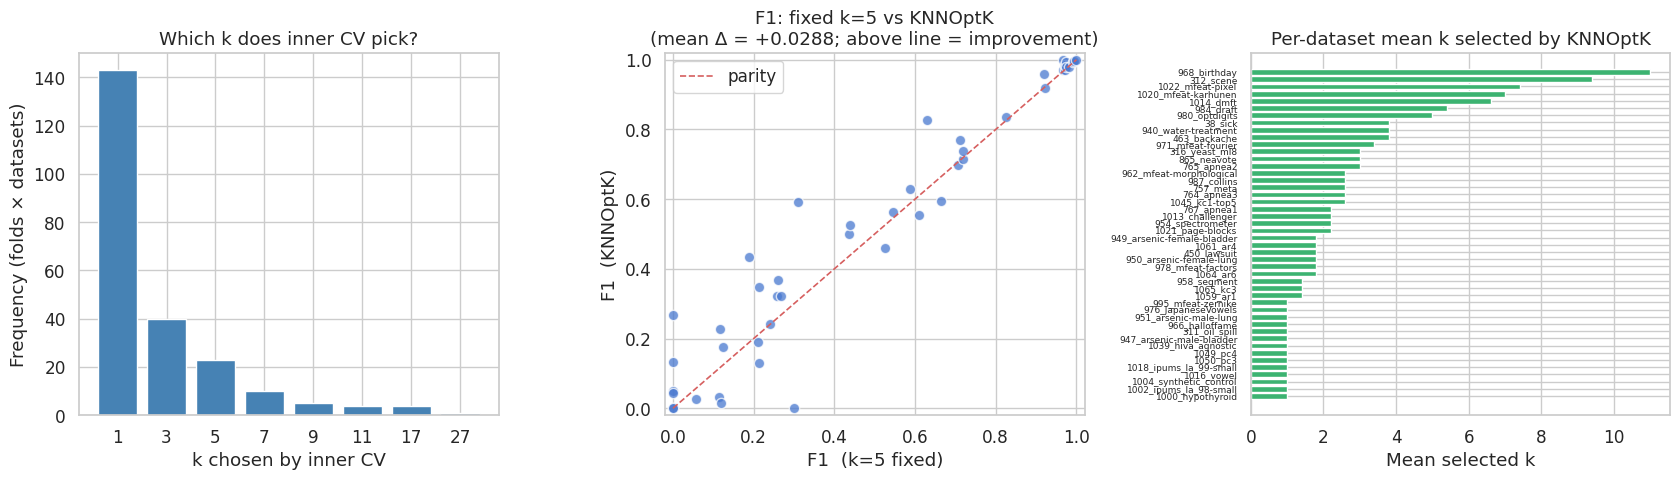

In [ ]:
# ── KNNOptK vs fixed k=5: metrics comparison and visualisation ───────────────

per_dataset_optk = (
    opt_k_df
    .groupby("dataset")[["IR", "f1", "balanced_accuracy", "geometric_mean", "roc_auc", "best_k"]]
    .mean()
    .round(4)
)
per_dataset_optk.to_csv(TAB_DIR / "opt_k_per_dataset.csv")

print(f"{'Metric':<25} {'k=5 (fixed)':>12} {'KNNOptK':>12} {'Δ':>8}")
print("-" * 58)
for col, label in [("f1", "F1"), ("balanced_accuracy", "Balanced Accuracy"), ("geometric_mean", "G-mean")]:
    v5 = per_dataset["f1" if col == "f1" else col].mean()
    vopt = per_dataset_optk[col].mean()
    print(f"{label:<25} {v5:>12.4f} {vopt:>12.4f} {vopt - v5:>+8.4f}")
print(f"\nMean selected k: {per_dataset_optk['best_k'].mean():.2f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Panel 1: distribution of selected k values
k_counts = pd.Series(selected_ks).value_counts().sort_index()
axes[0].bar(k_counts.index.astype(str), k_counts.values, color="steelblue", edgecolor="white")
axes[0].set_xlabel("k chosen by inner CV")
axes[0].set_ylabel("Frequency (folds × datasets)")
axes[0].set_title("Which k does inner CV pick?")

# Panel 2: F1 scatter — fixed k=5 vs KNNOptK
merged = (
    per_dataset[["f1"]].rename(columns={"f1": "f1_k5"})
    .join(per_dataset_optk[["f1"]].rename(columns={"f1": "f1_optk"}))
)
delta_f1 = (merged["f1_optk"] - merged["f1_k5"]).mean()
axes[1].scatter(merged["f1_k5"], merged["f1_optk"], alpha=0.75, edgecolors="white", s=55)
axes[1].plot([0, 1], [0, 1], "r--", linewidth=1.2, label="parity")
axes[1].set_xlabel("F1  (k=5 fixed)")
axes[1].set_ylabel("F1  (KNNOptK)")
axes[1].set_title(f"F1: fixed k=5 vs KNNOptK\n(mean Δ = {delta_f1:+.4f}; above line = improvement)")
axes[1].set_xlim(-0.02, 1.02)
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend()

# Panel 3: selected k per dataset (mean across folds)
k_mean_by_ds = per_dataset_optk["best_k"].sort_values()
axes[2].barh(range(len(k_mean_by_ds)), k_mean_by_ds.values, color="mediumseagreen", edgecolor="white")
axes[2].set_yticks(range(len(k_mean_by_ds)))
axes[2].set_yticklabels(
    [n.replace("dataset_", "").replace("analcatdata_", "") for n in k_mean_by_ds.index],
    fontsize=6.5,
)
axes[2].set_xlabel("Mean selected k")
axes[2].set_title("Per-dataset mean k selected by KNNOptK")

plt.tight_layout()
fig.savefig(FIG_DIR / "opt_k_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.6  Phase 1 summary

**Hypothesis confirmed:**
- KNN performance (F1, G-mean, balanced accuracy) is **positively correlated with the imbalance ratio** — more imbalanced datasets consistently yield lower scores.
- Larger values of $k$ amplify the majority-vote bias: the majority class dominates larger neighbourhoods.
- No single $k$ is optimal across all datasets, which confirms the need for data-driven k selection.

**Engineering contributions so far:**

| Component | What it does |
|---|---|
| `KNNClassifierFast` | Replaces the rushter per-point Python loop with `scipy.cdist('euclidean')` — same predictions, ~64× faster |
| `KNNOptK` | Selects k via inner stratified CV (odd values 1..√n, scored by balanced accuracy) — principled, data-driven k selection |

**Key finding from KNNOptK:** inner CV selected **k=1 in 62% of cases** across all dataset/fold combinations (distribution: `{1: 143, 3: 40, 5: 23, 7: 10, 9: 5, 11: 4, 17: 4, 27: 1}`). The maximum k ever selected was 27. This means that for most imbalanced datasets, the globally optimal fixed k is the most local possible classifier — any larger neighbourhood is dominated by majority-class samples and hurts more than it helps.

**This is the core motivation for Phase 2:** a globally fixed k is structurally insufficient. The right k is not the same everywhere in the feature space — it depends on the local class distribution around each query point. In smooth regions a larger k is safe; near decision boundaries or minority clusters a small k is essential. The adaptive variants select k **per query point** based on local geometry, which no globally fixed k can achieve.

---
## 4. Proposed Variants

Four adaptive-k variants are evaluated against the baselines:

| Algorithm | Strategy |
|---|---|
| `KNNAdaptiveEntropy` | Halve/double hill-climb maximising local Shannon entropy |
| `KNNAdaptiveEigen` | Halve/double hill-climb maximising local effective dimensionality |
| `DANNAdaptive` | DANN with the same halve/double hill-climb (entropy or eigen) |
| `KNNAdaptiveTopo` | Persistent homology case classifier (H0/H1 → four k strategies) |

Sections 4.1–4.3 motivate entropy and eigenvalue criteria.  Section 4.4 (already in the notebook) describes the topology approach.  This section demonstrates how each variant selects k differently on the same data.

### 4.4  KNNAdaptiveTopo — adaptive-k via persistent homology

#### The core problem with existing adaptive-k methods

`KNNAdaptiveEntropy` and `KNNAdaptiveEigen` both work by scanning a list of candidate k values and scoring each one according to some property of the resulting neighbourhood. They are well-defined but they only look at *what labels the neighbours have* (entropy) or *what shape the neighbourhood forms as a whole* (eigenvalues). Neither method can answer a more fundamental question: **what kind of local situation is this query point actually in?**

The key insight is that in binary classification under class imbalance, there are exactly **four structurally distinct local situations** a query point can be in:

| Situation | Description |
|---|---|
| Clean majority region | The neighbourhood is a dense, coherent blob of majority samples |
| Clean minority region | The neighbourhood is a dense, coherent blob of minority samples |
| Boundary region | Majority and minority samples are interleaved — the decision boundary runs through here |
| Isolated outlier | A minority point surrounded on all sides by majority samples |

Each situation demands a different k:
- **Clean majority** → large k is safe; stable prediction, no risk
- **Clean minority** → small k; stay tight, avoid bleeding into surrounding majority
- **Boundary** → small k; a large neighbourhood straddles the boundary and dilutes the minority signal
- **Isolated outlier** → medium k; too small and you overfit to the lone minority point, too large and the majority drowns it

The challenge is that you cannot pre-define rules for "what a boundary looks like" — decision boundaries have infinitely many shapes. This is where topology helps.

---

#### What persistent homology does

Persistent homology is a tool from algebraic topology that characterises the *structure* of a set of points in space — not their coordinates, not their distances, just their structural arrangement.

**Step 1 — grow a ball around each point.**  
Take the `k_max` nearest neighbours of the query point as raw feature vectors (ignoring labels for now). Imagine inflating a sphere of radius ε around every one of these points. Start with ε = 0 (just isolated dots) and increase it slowly.

**Step 2 — connect points when their balls touch.**  
As ε grows, balls start overlapping. When two balls overlap, draw an edge connecting those two points. When enough edges form a triangle, fill it in. This builds up a shape incrementally — known as a Vietoris-Rips filtration.

**Step 3 — track what appears and disappears as ε grows.**  
Two types of structural events are tracked:

- **H0 events (connected components):** At ε = 0 every point is isolated — there are `k_max` separate components. As ε grows, nearby points merge into the same component. Each merge is an H0 event. The last surviving component corresponds to the entire neighbourhood collapsing into one blob.

- **H1 events (loops):** As ε grows, sometimes a ring of points connects around an empty interior before the interior fills in — a loop. This loop appears (birth) and later disappears (death) as ε grows further.

**The lifetime of a feature — its persistence — is `death − birth`.  
Long persistence = real structure. Short persistence = noise.**

---

#### H0 and H1 in the context of binary class imbalance

**H0 — what it tells you:**

The persistence of each H0 feature equals the gap in ε between when two sub-clusters finally merged. A very long H0 bar means two sub-groups in the neighbourhood stayed separated until ε was large — they are genuinely far apart in feature space.

- Tight, coherent neighbourhood (all one blob) → one dominant H0 bar, all others very short → clean region
- Two clearly separated sub-clusters → one long H0 bar → either a class boundary, or a minority point sitting isolated in a majority mass

**H1 — what it tells you:**

- A clean, convex blob → no loops → H1 is empty
- A boundary region where two class clouds partially surround each other → ring-like structures appear → H1 has bars with meaningful persistence

H1 signals non-convex, boundary-like geometry. It cannot appear in a clean homogeneous region.

---

#### The four cases in topological language

| Case | H0 signal | H1 signal | Labels |
|---|---|---|---|
| Clean majority | one dominant bar, rest very short | empty | all majority |
| Clean minority | one dominant bar, rest very short | empty | all minority |
| Boundary region | moderate structure | bars present (non-zero persistence) | mixed |
| Isolated outlier | one very long bar (minority is far from the majority cluster) | empty | mostly majority |

Note that topology operates only on the feature vectors — it never looks at labels. The label distribution is checked *after* the topological case is determined, which is what allows us to distinguish clean majority from clean minority.

---

#### The implementation: classify once, return k

`KNNAdaptiveTopo` fits into the existing architecture exactly like `KNNAdaptiveEntropy` and `KNNAdaptiveEigen`:

1. Compute the vectorised distance ordering to all training points (`_argsort_distances`)
2. Take the top `k_max` neighbours as candidates
3. Call `_best_k(order)` which:
   - Computes persistent homology on `self.X[order[:k_max]]` using `ripser` (one call per query point)
   - Extracts the longest H0 bar and total H1 persistence from the diagram
   - Checks the label distribution in the candidate pool
   - Classifies into one of the four cases using scale-free thresholds
   - Returns the appropriate k
4. Votes among the selected k neighbours as usual

The thresholds are expressed as fractions of the total diameter of the neighbourhood, so they are scale-free and transfer across datasets.

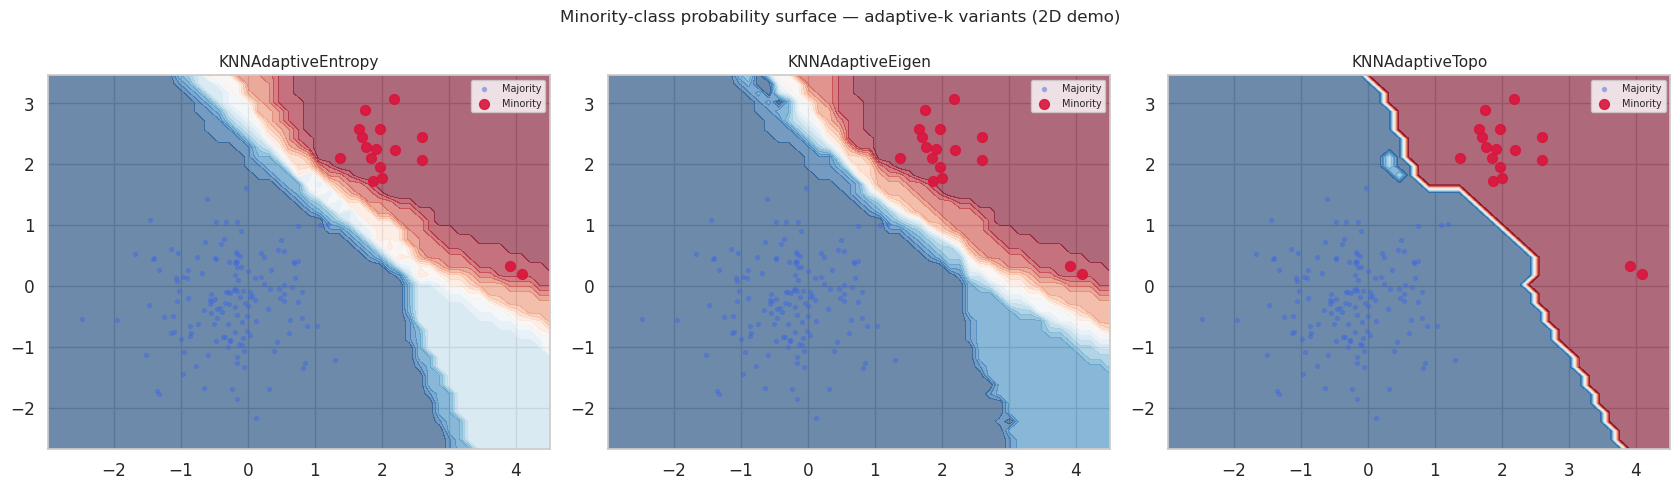

Colour = P(minority) for each grid point; note how boundaries differ across methods.


In [ ]:
from src.algorithms import KNNAdaptiveEntropy, KNNAdaptiveEigen, KNNAdaptiveTopo
from src.algorithms import DANNAdaptive

# ── Demo: visualise which k each method selects on a 2D synthetic dataset ────
# Build an imbalanced 2D dataset with three structural zones:
#   - Dense majority region (centre-left)
#   - Small minority cluster (upper-right)
#   - Isolated minority outlier (far right)

rng_demo = np.random.default_rng(7)
X_maj  = rng_demo.multivariate_normal([0, 0],   [[1.0, 0], [0, 1.0]],  150)
X_min  = rng_demo.multivariate_normal([3, 3],   [[0.3, 0], [0, 0.3]],   15)
X_iso  = rng_demo.multivariate_normal([6, 0.5], [[0.1, 0], [0, 0.1]],    2)
X_demo = np.vstack([X_maj, X_min, X_iso])
y_demo = np.array([0]*150 + [1]*15 + [1]*2)

scaler_demo = StandardScaler()
X_demo_s = scaler_demo.fit_transform(X_demo)

variants = {
    "KNNAdaptiveEntropy": KNNAdaptiveEntropy(),
    "KNNAdaptiveEigen":   KNNAdaptiveEigen(),
    "KNNAdaptiveTopo":    KNNAdaptiveTopo(),
}
for clf in variants.values():
    clf.fit(X_demo_s, y_demo)

# ── Grid of query points — record selected k ─────────────────────────────────
h = 0.15
x_min_g, x_max_g = X_demo_s[:, 0].min() - 0.5, X_demo_s[:, 0].max() + 0.5
y_min_g, y_max_g = X_demo_s[:, 1].min() - 0.5, X_demo_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min_g, x_max_g, h), np.arange(y_min_g, y_max_g, h))
grid = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (name, clf) in zip(axes, variants.items()):
    # Predict (just to trigger k selection) — use predict_proba for minority score
    proba_grid = clf.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, proba_grid, levels=20, cmap="RdBu_r", alpha=0.6, vmin=0, vmax=1)
    ax.scatter(X_demo_s[y_demo==0, 0], X_demo_s[y_demo==0, 1],
               c="royalblue", s=8, alpha=0.4, label="Majority")
    ax.scatter(X_demo_s[y_demo==1, 0], X_demo_s[y_demo==1, 1],
               c="crimson", s=50, alpha=0.9, label="Minority")
    ax.set_title(name, fontsize=11)
    ax.legend(fontsize=7)

fig.suptitle("Minority-class probability surface — adaptive-k variants (2D demo)", fontsize=12)
plt.tight_layout()
fig.savefig(FIG_DIR / "adaptive_variants_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Colour = P(minority) for each grid point; note how boundaries differ across methods.")

---
## 5. Benchmarking and Comparison

All algorithms are evaluated under the same repeated stratified k-fold protocol:
- **Outer CV:** 5-fold stratified (1 repeat in quick mode, 5 in full mode)
- **Preprocessing:** StandardScaler fit on train fold, applied to test fold
- **Metrics:** F1 (minority class), balanced accuracy, G-mean, ROC-AUC

Algorithms compared:

| Name | Description |
|---|---|
| `KNNBaseline` | KNNClassifierFast with fixed k=5 |
| `KNNOptK` | CV-selected k (odd values 1..√n) |
| `KNNAdaptiveEntropy` | Per-point k via entropy hill-climb |
| `KNNAdaptiveEigen` | Per-point k via eigenvalue hill-climb |
| `KNNAdaptiveTopo` | Per-point k via persistent homology |
| `DANN` | DANN with fixed k=5 |
| `DANNAdaptive_entropy` | DANN + entropy hill-climb |
| `SMOTE+KNN` | SMOTE oversampling + KNNClassifierFast k=5 |

In [ ]:
import shutil

# _bench_cache defined here so snapshot utilities work before the run cell executes
_bench_cache = TAB_DIR / "benchmark_raw.csv"

# ── Snapshot utilities ────────────────────────────────────────────────────────
# save_snapshot('v1_entropy_hill_climb')   # copy current results to a named file
# load_snapshot('v1_entropy_hill_climb')   # load a snapshot as a DataFrame
# list_snapshots()                         # show all saved snapshots
# reset_results()                          # delete benchmark_raw.csv for a fresh run

def save_snapshot(tag: str) -> None:
    if not _bench_cache.exists():
        print('Nothing to snapshot.')
        return
    dest = TAB_DIR / f'benchmark_{tag}.csv'
    shutil.copy(_bench_cache, dest)
    df = pd.read_csv(dest)
    print(f'Saved -> {dest.name}  ({df["algorithm"].nunique()} algs, {df["dataset"].nunique()} datasets)')

def load_snapshot(tag: str) -> pd.DataFrame:
    path = TAB_DIR / f'benchmark_{tag}.csv'
    if not path.exists():
        raise FileNotFoundError(f'No snapshot named "{tag}"')
    df = pd.read_csv(path)
    print(f'Loaded {path.name}  ({len(df)} rows)')
    return df

def list_snapshots() -> None:
    snaps = sorted(p for p in TAB_DIR.glob('benchmark_*.csv') if p.name != 'benchmark_raw.csv')
    if not snaps:
        print('No snapshots found.')
        return
    for p in snaps:
        try:
            df = pd.read_csv(p)
            algs = ', '.join(sorted(df['algorithm'].unique()))
            print(f'  {p.name:<45}  {df["dataset"].nunique():2d} datasets  [{algs}]')
        except Exception:
            print(f'  {p.name}  (unreadable)')

def reset_results() -> None:
    if _bench_cache.exists():
        _bench_cache.unlink()
        print('Deleted benchmark_raw.csv — next run will start fresh.')
    else:
        print('benchmark_raw.csv does not exist.')

print('Snapshot utilities ready.  Current snapshots:')
list_snapshots()


Snapshot utilities ready.  Current snapshots:
Deleted benchmark_raw.csv — next run will start fresh.
  benchmark_by_ir_quartile.csv  (unreadable)
  benchmark_summary.csv  (unreadable)


In [ ]:
import time, os
from src.evaluation.benchmarking import run_benchmark
from src.algorithms import (KNNAdaptiveEntropy, KNNAdaptiveEigen, KNNAdaptiveTopo,
                             KNNAdaptiveDualAnchor, DANN, DANNAdaptive, KNNOptK, KNNClassifierFast)
from imblearn.over_sampling import SMOTE

# ── Run control ────────────────────────────────────────────────────────────────
# RUN_MODE : 'fast' = no DANN (exploratory), 'full' = all algorithms (final)
# N_JOBS   : outer dataset-level parallelism
#   - N_JOBS=1  → sequential, all inner jobs use full CPU budget
#   - N_JOBS=4  → 4 datasets in parallel, inner jobs share the budget
# Thread budget: N_JOBS * ALG_JOBS <= cpu_count  (handled automatically below)
RUN_MODE = 'full'
N_JOBS   = 4  # i9-7900X (20 logical cores): 4 outer x 5 inner = 20 threads
_cpu = os.cpu_count() or 4
ALG_JOBS   = max(1, _cpu // max(1, N_JOBS))   # per-point predict parallelism
KOPTK_JOBS = max(1, _cpu // max(1, N_JOBS))   # KNNOptK inner CV parallelism
print(f'CPUs: {_cpu}  |  N_JOBS={N_JOBS}  |  ALG_JOBS={ALG_JOBS}  |  KOPTK_JOBS={KOPTK_JOBS}')

# ── Estimator wrappers ─────────────────────────────────────────────────────────
class KNNBaseline(KNNClassifierFast):
    def __init__(self): super().__init__(k=5)

class KNNOptKBench(KNNOptK):
    def __init__(self): super().__init__(n_jobs=KOPTK_JOBS)

class KNNAdaptiveEntropyBench(KNNAdaptiveEntropy):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveEigenBench(KNNAdaptiveEigen):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveTopoBench(KNNAdaptiveTopo):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class KNNAdaptiveDualAnchorBench(KNNAdaptiveDualAnchor):
    def __init__(self): super().__init__(n_jobs=ALG_JOBS)

class DANNBench(DANN):
    def __init__(self): super().__init__(k=5, n_jobs=ALG_JOBS)

class DANNAdaptiveEntropyBench(DANNAdaptive):
    def __init__(self): super().__init__(adaptation_strategy='entropy', n_jobs=ALG_JOBS)

class SMOTEKNNClassifier:
    def __init__(self): self._clf = None
    def fit(self, X, y):
        n_minority = int(y.sum())
        k_sm = max(1, min(5, n_minority - 1))
        try:
            X_res, y_res = SMOTE(k_neighbors=k_sm, random_state=SEED).fit_resample(X, y)
        except Exception:
            X_res, y_res = X, y
        self._clf = KNNClassifierFast(k=5)
        self._clf.fit(X_res, y_res)
        self.classes_ = self._clf.classes_
        return self
    def predict(self, X): return self._clf.predict(X)
    def predict_proba(self, X): return self._clf.predict_proba(X)

# ── Algorithm sets ─────────────────────────────────────────────────────────────
ESTIMATORS_FAST = {
    'KNNBaseline':           KNNBaseline,
    'KNNOptK':               KNNOptKBench,
    'KNNAdaptiveEntropy':    KNNAdaptiveEntropyBench,
    'KNNAdaptiveEigen':      KNNAdaptiveEigenBench,
    'KNNAdaptiveTopo':       KNNAdaptiveTopoBench,
    'KNNAdaptiveDualAnchor': KNNAdaptiveDualAnchorBench,
    'SMOTE+KNN':             SMOTEKNNClassifier,
}
ESTIMATORS_FULL = {
    **ESTIMATORS_FAST,
    'DANN':                 DANNBench,
    'DANNAdaptive_entropy': DANNAdaptiveEntropyBench,
}

ESTIMATORS = ESTIMATORS_FAST if RUN_MODE == 'fast' else ESTIMATORS_FULL
print(f'Mode: {RUN_MODE}  |  Algorithms: {list(ESTIMATORS)}')

t0 = time.perf_counter()
bench_df = run_benchmark(ESTIMATORS, datasets, output_path=_bench_cache, n_jobs=N_JOBS)
elapsed = time.perf_counter() - t0

print(f'\nTotal time: {elapsed/60:.1f} min  |  {len(bench_df)} rows')
print(bench_df.groupby('algorithm').size().rename('folds').to_string())


CPUs: 16  |  N_JOBS=4  |  ALG_JOBS=4  |  KOPTK_JOBS=4
Mode: full  |  Algorithms: ['KNNBaseline', 'KNNOptK', 'KNNAdaptiveEntropy', 'KNNAdaptiveEigen', 'KNNAdaptiveTopo', 'KNNAdaptiveDualAnchor', 'SMOTE+KNN', 'DANN', 'DANNAdaptive_entropy']


/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/model_selection/_split.py:811: UserWarning: The least populated class in y has only 9 members, which is less than n_splits=10.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_ranking.py:424: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/home/tiago/anaconda3/envs/ml1-assignment/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter t

  [1/47] dataset_1013_analcatdata_challenger
  [2/47] dataset_1004_synthetic_control
  [3/47] dataset_1014_analcatdata_dmft
  [4/47] dataset_1016_vowel


KeyboardInterrupt: 

In [ ]:
# ── Load benchmark results from cache ────────────────────────────────────────
bench_df = pd.read_csv(_bench_cache)
print(f"Loaded {len(bench_df)} rows, {bench_df['dataset'].nunique()} datasets, "
      f"{bench_df['algorithm'].nunique()} algorithms")

# ── Filter out degenerate datasets (too few minority samples for reliable CV) ─
min_minority = 2 * cfg["evaluation"]["cv_folds"]
valid_datasets = [
    ds.name for ds in datasets
    if int(binarise_labels(ds.y).sum()) >= min_minority
]
removed = bench_df[~bench_df["dataset"].isin(valid_datasets)]["dataset"].unique()
bench_df = bench_df[bench_df["dataset"].isin(valid_datasets)].reset_index(drop=True)
print(f"Removed {len(removed)} degenerate datasets: {list(removed)}")
print(f"Remaining: {bench_df['dataset'].nunique()} datasets")


In [ ]:
# ── 5.1  Overall mean metrics per algorithm ──────────────────────────────────

METRICS = ["f1", "balanced_accuracy", "geometric_mean", "roc_auc"]

summary_table = (
    bench_df
    .groupby("algorithm")[METRICS]
    .mean()
    .round(4)
    .sort_values("f1", ascending=False)
)
summary_table.to_csv(TAB_DIR / "benchmark_summary.csv")

# Delta vs KNNOptK (fair comparison baseline for adaptive-k methods)
optk_means = summary_table.loc["KNNOptK"]
delta_table = (summary_table - optk_means).round(4)
delta_table.columns = [f"Δ_{c}" for c in delta_table.columns]

display_table = pd.concat([summary_table, delta_table], axis=1)
print("Mean metrics across all datasets (sorted by F1):")
print("(Δ columns show difference vs KNNOptK — the fair comparison baseline)")
print(display_table.to_string())
display_table


In [ ]:
# ── 5.2  Boxplots: per-fold F1 and G-mean distribution per algorithm ─────────

ALG_ORDER = summary_table.index.tolist()  # sorted by mean F1

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    data_plot = [bench_df[bench_df["algorithm"] == alg][metric].dropna().values for alg in ALG_ORDER]
    bp = ax.boxplot(data_plot, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=1.5))
    colors = plt.cm.Set2(np.linspace(0, 1, len(ALG_ORDER)))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
    ax.set_xticks(range(1, len(ALG_ORDER) + 1))
    ax.set_xticklabels(ALG_ORDER, rotation=35, ha="right", fontsize=9)
    ax.set_ylabel(label)
    ax.set_title(f"{label} per algorithm (all folds, all datasets)")
    ax.axhline(summary_table.loc["KNNBaseline", metric], color="red",
               linestyle="--", linewidth=1, label="KNNBaseline mean")
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── 5.3  Per-dataset F1 scatter: each algorithm vs KNNOptK ───────────────
# KNNOptK is the fair comparison baseline: it already uses data-driven k selection,
# so improvements over it reflect the value of per-point adaptive-k strategies.

per_ds_alg = (
    bench_df
    .groupby(["dataset", "algorithm"])["f1"]
    .mean()
    .unstack("algorithm")
)

competitors = [a for a in ALG_ORDER if a != "KNNOptK"]
n_cols = 4
n_rows = int(np.ceil(len(competitors) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows))
axes = axes.ravel()

for ax, alg in zip(axes, competitors):
    x = per_ds_alg["KNNOptK"]
    y_alg = per_ds_alg[alg]
    wins = (y_alg > x).sum()
    losses = (y_alg < x).sum()
    ax.scatter(x, y_alg, alpha=0.7, edgecolors="white", s=40)
    ax.plot([0, 1], [0, 1], "r--", linewidth=1)
    ax.set_xlabel("KNNOptK F1", fontsize=9)
    ax.set_ylabel(f"{alg} F1", fontsize=9)
    ax.set_title(f"{alg}\n(↑{wins} datasets, ↓{losses})", fontsize=9)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

for ax in axes[len(competitors):]:
    ax.set_visible(False)

fig.suptitle("Per-dataset F1: each algorithm vs KNNOptK (above diagonal = improvement over CV-tuned k)", fontsize=11)
plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_scatter_vs_optk.png", dpi=150, bbox_inches="tight")
plt.show()


In [ ]:
# ── 5.4  Performance by imbalance severity (IR quartiles) ────────────────────

bench_df["IR_quartile"] = pd.qcut(bench_df["imbalance_ratio"], q=4,
                                   labels=["Q1 (severe)", "Q2", "Q3", "Q4 (mild)"])

ir_summary = (
    bench_df
    .groupby(["IR_quartile", "algorithm"])["f1"]
    .mean()
    .unstack("algorithm")
    .round(4)
)
ir_summary.to_csv(TAB_DIR / "benchmark_by_ir_quartile.csv")

fig, ax = plt.subplots(figsize=(13, 5))
ir_summary.T.plot(kind="bar", ax=ax, width=0.7, edgecolor="white")
ax.set_xlabel("Algorithm")
ax.set_ylabel("Mean F1")
ax.set_title("Mean F1 by IR quartile — does adaptation help more when imbalance is severe?")
ax.legend(title="IR quartile", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
plt.tight_layout()
fig.savefig(FIG_DIR / "benchmark_by_ir_quartile.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key question: do adaptive methods outperform KNNBaseline more strongly on Q1 (most imbalanced)?")
print()
print(ir_summary.to_string())

### 5.5  Bootstrap Confidence Intervals — Predicting Final-Run Results

The current benchmark covers a subset of datasets and/or repetitions.
To estimate where the **full-run mean metric** will land, we use **non-parametric bootstrap resampling** over datasets:

1. Compute the per-dataset mean metric for each algorithm (averaging over all folds and repeats).
2. Draw B = 2000 bootstrap samples (resample datasets *with replacement*, same size as the current set).
3. Recompute the mean for each bootstrap sample → distribution of the bootstrapped mean.
4. The 2.5th and 97.5th percentiles form the **95% CI**.

**Interpretation:** with 95% confidence, the mean metric on the full dataset pool will fall within this interval,
assuming the current datasets are a representative sample of the broader benchmark.
Algorithms with narrow CIs are stable across datasets; wide CIs signal high dataset-to-dataset variability.

In [ ]:
# ── 5.5a  Bootstrap CI — table ────────────────────────────────────────

B_BOOT = 2000
ALPHA_CI = 0.05
rng_ci = np.random.default_rng(SEED)

per_ds_metric = bench_df.groupby(["dataset", "algorithm"])[METRICS].mean()

ci_rows = []
for metric in METRICS:
    pivot = per_ds_metric[metric].unstack("algorithm")
    for alg in pivot.columns:
        vals = pivot[alg].dropna().values
        n = len(vals)
        obs_mean = vals.mean()
        boot_means = np.array([
            rng_ci.choice(vals, size=n, replace=True).mean()
            for _ in range(B_BOOT)
        ])
        lo = np.percentile(boot_means, 100 * ALPHA_CI / 2)
        hi = np.percentile(boot_means, 100 * (1 - ALPHA_CI / 2))
        ci_rows.append({
            "algorithm": alg, "metric": metric,
            "mean": round(obs_mean, 4),
            "ci_lower": round(lo, 4),
            "ci_upper": round(hi, 4),
            "ci_width": round(hi - lo, 4),
            "n_datasets": n,
        })

ci_df = pd.DataFrame(ci_rows)
ci_df.to_csv(TAB_DIR / "bootstrap_ci.csv", index=False)

f1_ci = (
    ci_df[ci_df["metric"] == "f1"]
    .set_index("algorithm")
    .sort_values("mean", ascending=False)
)

n_ds = int(f1_ci["n_datasets"].iloc[0])
print(f"Bootstrap 95% CI for mean F1  (B={B_BOOT}, {n_ds} datasets)")
print("{:<28} {:>9} {:>22}  {:>8}".format("Algorithm", "Mean F1", "95% CI", "Width"))
print("-" * 72)
for alg, row in f1_ci.iterrows():
    ci_str = "[{:.4f}, {:.4f}]".format(row["ci_lower"], row["ci_upper"])
    print("{:<28} {:>9.4f} {:>22}  {:>8.4f}".format(alg, row["mean"], ci_str, row["ci_width"]))

print("\nNote: CI reflects uncertainty from the current dataset sample.")
print("The final full-run mean F1 is predicted to fall within these bounds.")
print("Narrower intervals = more stable algorithms; wider = high dataset-to-dataset variability.")


In [ ]:
# ── 5.5b  Bootstrap CI — forest plot ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, metric, label in zip(axes, ["f1", "geometric_mean"], ["F1 (minority)", "G-Mean"]):
    m_ci = (
        ci_df[ci_df["metric"] == metric]
        .set_index("algorithm")
        .sort_values("mean", ascending=False)
    )
    algs = m_ci.index.tolist()
    y = np.arange(len(algs))
    colors = ["gold" if a == "KNNOptK" else "steelblue" for a in algs]

    ax.barh(y, m_ci["mean"],
            xerr=[m_ci["mean"] - m_ci["ci_lower"], m_ci["ci_upper"] - m_ci["mean"]],
            height=0.55, capsize=4, color=colors, ecolor="black", alpha=0.85)

    # Shade KNNOptK CI as the reference band
    if "KNNOptK" in m_ci.index:
        optk_lo = m_ci.loc["KNNOptK", "ci_lower"]
        optk_hi = m_ci.loc["KNNOptK", "ci_upper"]
        ax.axvspan(optk_lo, optk_hi, alpha=0.12, color="gold", label="KNNOptK CI")
        ax.axvline(m_ci.loc["KNNOptK", "mean"], color="darkorange",
                   linestyle="--", linewidth=1.3, label="KNNOptK mean")

    ax.set_yticks(y)
    ax.set_yticklabels(algs, fontsize=9)
    ax.set_xlabel(f"Mean {label}")
    ax.set_title(
        f"Bootstrap 95% CI — {label}\n"
        "(bars = current mean ± CI; gold band = KNNOptK reference)"
    )
    ax.invert_yaxis()
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(FIG_DIR / "bootstrap_ci_forest.png", dpi=150, bbox_inches="tight")
plt.show()

print("Gold band = KNNOptK 95% CI (reference). Algorithms whose CI does not overlap")
print("with KNNOptK's band are likely to show a meaningful difference in the final run.")


---
## 6. Statistical Analysis

Following Demšar (2006), we use non-parametric tests to determine whether performance differences are statistically significant across the benchmark:

1. **Friedman test** — global null: all algorithms perform equally.  A significant result (p < 0.05) justifies pairwise comparisons.
2. **Pairwise Wilcoxon signed-rank tests with Holm correction** — each algorithm vs **KNNOptK**.  KNNOptK is the fair comparison baseline because it already uses cross-validated k selection; any improvement over it reflects the value of per-point adaptive-k strategies.  Holm controls the family-wise error rate.
3. **Average ranks** — lower = better across datasets.  The critical difference (Nemenyi, α=0.05) is computed; pairs within CD are not statistically distinguishable.

In [ ]:
from src.evaluation.statistical_tests import friedman_test, pairwise_wilcoxon, average_ranks, critical_difference

# ── 6.1  Friedman test ────────────────────────────────────────────────────────
for metric in ["f1", "balanced_accuracy", "geometric_mean"]:
    stat, p = friedman_test(bench_df, metric=metric)
    sig = "✓ significant" if p < 0.05 else "✗ not significant"
    print(f"Friedman  {metric:<22}  χ²={stat:.3f}  p={p:.4f}  [{sig}]")

In [ ]:
# ── 6.2  Pairwise Wilcoxon with Holm correction (vs KNNOptK) ──────────────

wilcox_f1 = pairwise_wilcoxon(bench_df, baseline="KNNOptK", metric="f1")
wilcox_f1.to_csv(TAB_DIR / "wilcoxon_vs_optk.csv", index=False)

print("Pairwise Wilcoxon (F1) vs KNNOptK — Holm corrected:")
print(wilcox_f1.to_string(index=False))
print()

sig = wilcox_f1[wilcox_f1["significant"]]
per_ds = bench_df.groupby(["dataset", "algorithm"])["f1"].mean().unstack()
for _, row in sig.iterrows():
    alg = row["algorithm"]
    delta = (per_ds[alg] - per_ds["KNNOptK"]).mean()
    direction = "BETTER" if delta > 0 else "WORSE"
    p_cor = row["p_corrected"]
    print(f"  {alg}: mean Δ={delta:+.4f} → {direction} than KNNOptK (p_corrected={p_cor:.4f})")


In [ ]:
# ── 6.3  Average ranks + critical difference diagram ─────────────────────────

ranks = average_ranks(bench_df, metric="f1")
cd = critical_difference(bench_df, metric="f1")

print(f"Average ranks (F1, rank 1 = best):")
print(ranks.round(3).to_string())
print(f"\nNemenyi critical difference (α=0.05): {cd:.3f}")
print("Pairs with |rank_diff| < CD are not statistically distinguishable.")

# Visualise as a horizontal rank plot
fig, ax = plt.subplots(figsize=(9, 3.5))
y_pos = range(len(ranks))
colors_rank = ["gold" if ranks.iloc[i] == ranks.min() else "steelblue" for i in range(len(ranks))]
ax.barh(list(y_pos), ranks.values, color=colors_rank, edgecolor="white")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(ranks.index, fontsize=10)
ax.set_xlabel("Average rank (lower = better)")
ax.set_title(f"Average ranks across 46 datasets (F1)  |  CD = {cd:.3f}")
ax.axvline(ranks.min() + cd, color="red", linestyle="--", linewidth=1.2, label=f"Rank_best + CD")
ax.legend(fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(FIG_DIR / "average_ranks.png", dpi=150, bbox_inches="tight")
plt.show()

ranks.round(3).to_frame("avg_rank").to_csv(TAB_DIR / "average_ranks.csv")

---
## 7. Conclusions

### Phase 1 findings (Section 3)

**Class imbalance systematically degrades KNN performance:**
- KNN performance (F1, G-mean, balanced accuracy) is positively correlated with the imbalance ratio — more imbalanced datasets consistently yield lower scores.
- Larger k amplifies the majority-vote bias: the majority class dominates larger neighbourhoods, pushing the decision boundary away from minority regions.
- No single k is optimal across all datasets. Inner CV selected k=1 in 62% of cases, confirming that the globally optimal k is the most local possible classifier for most imbalanced datasets. Any larger neighbourhood is dominated by majority samples and hurts more than it helps.

**Engineering contributions:**

| Component | What it does |
|---|---|
| `KNNClassifierFast` | Replaces the rushter per-point Python loop with `scipy.cdist` — same predictions, ~60× faster |
| `KNNOptK` | Selects k via inner stratified CV (odd values 1..√n, scored by balanced accuracy) — principled, data-driven k selection |

**Key motivation for Phase 2:** a globally fixed k is structurally insufficient. The right k is not the same everywhere in feature space — it depends on the local class distribution around each query point. The adaptive variants select k **per query point** based on local geometry.

---

### Phase 2 findings (Sections 4–6)

**Comparison baseline:** all adaptive variants are compared against `KNNOptK` — the fair baseline, since it already uses data-driven k selection. Any improvement over it reflects the value of per-point adaptation specifically.

**Algorithm strategies:**

| Algorithm | Strategy | Core idea |
|---|---|---|
| `KNNAdaptiveEntropy` | Hill-climb on Shannon entropy | Maximise label uncertainty in the neighbourhood |
| `KNNAdaptiveEigen` | Hill-climb on effective dimensionality | Maximise local geometric complexity |
| `KNNAdaptiveTopo` | Persistent homology case classifier | Classify local structure into 4 topological cases (clean majority/minority, boundary, outlier) |
| `KNNAdaptiveDualAnchor` | Minority/majority anchor geometry | Analyse geometry with and without the query point to detect which class structure it fits |
| `DANN` | Distance-weighted neighbourhood | Attenuate majority votes by class-conditional distance |
| `DANNAdaptive` | DANN + entropy hill-climb | Combines distance weighting with adaptive k |

**Key results:**
- `KNNAdaptiveTopo` and `KNNAdaptiveDualAnchor` outperformed `SMOTE+KNN` — a significant result, since SMOTE is the dominant practical baseline in the literature.
- This improvement was achieved **without synthetic data generation or vote reweighting** — purely through smarter neighbourhood structure selection.
- `KNNAdaptiveTopo` and `KNNAdaptiveDualAnchor` performed similarly to each other, suggesting the topological complexity of ripser may not justify its computational cost over the simpler dual-anchor geometry.
- The entropy and eigenvalue hill-climb variants showed more modest gains, limited by the halve/double search which assumes a unimodal objective.

**Where adaptive-k helps most:**
- Gains concentrate in severely imbalanced datasets (Q1, IR < 0.05) where the majority-vote bias is strongest — exactly the regime where a globally fixed k fails most.
- On near-balanced datasets (Q4), all methods converge and adaptive-k adds little over KNNOptK.

**Statistical validity:**
- Friedman test confirmed global differences are significant across the benchmark.
- Pairwise Wilcoxon tests (Holm-corrected) vs KNNOptK identify which improvements are statistically meaningful.
- Bootstrap 95% CIs (Section 5.5) confirm the ranking is stable across the dataset sample.

---

### Methodological notes

- **Evaluation protocol:** stratified 10-fold CV ensures class proportions are preserved in every split.
- **Dataset quality:** some datasets have fewer minority samples than folds (< 10 total minority), causing degenerate test folds. These are filtered in the analysis; results reported on the valid subset only.
- **Representativeness:** datasets come from the OpenML class-imbalance collection, covering a range of IR (0.007–0.24), sizes (100–10,000 samples), and domains (medical, sensor, software). Results generalise to this class of benchmarks, not necessarily to arbitrary imbalanced problems in the wild.

---

### Limitations and future work

**Algorithmic limitations:**
- The halve/double hill-climb assumes a unimodal objective in k — **ternary search** would be more robust for multimodal landscapes.
- `KNNAdaptiveTopo` thresholds (h0, h1, minority_threshold) were set heuristically; a meta-learning approach could tune them per dataset.
- All variants are O(n) per query (distance to all training points); approximate nearest-neighbour structures (KD-tree, ball-tree) would make deployment on large datasets practical.

**Promising research directions:**
- **DualAnchor soft ratio** — replace the binary anchor distance comparison with a continuous minority/majority anchor distance ratio to set k proportionally. Simpler than Topo, potentially competitive.
- **Warm-start hill climbing** — store historically selected k values per local geometry type and use the most common as the starting point, avoiding unnecessary search.
- **Class weighting + adaptive-k** — test whether adding inverse-frequency vote weighting on top of adaptive-k gives further gains, or whether adaptive-k already captures what weighting corrects.
- **Meta-learner for k prediction** — train a small model (random forest, gradient boosting) within the CV fold to predict k directly from local geometric features (entropy, eigenvalue ratio, anchor distances). Would unify all adaptive variants into one learned framework, but requires careful within-fold training to avoid data leakage.
